<a href="https://colab.research.google.com/github/nimitraheja/nimitraheja/blob/main/nimit1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Removing outlier methods

Method 1- IQR(INTER QUARTILE RANGE)

In [6]:
import numpy as np
ages=[23,24,32,45,12,43,67,45,32,56,32,120]
q1,q3=np.percentile(ages,[25,75])
print(q1,q3)
IQR= q3-q1
print(IQR)
lower_bound=q1-(1.5*IQR)
upper_bound=q3+(1.5*IQR)
print(lower_bound,upper_bound)
outliers=[]
for i in ages:
   if i<lower_bound or i>upper_bound:
      outliers.append(i)
      print(outliers)



30.0 47.75
17.75
3.375 74.375
[120]


Method -2 Zscore test

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

# Sample dataframe
df = pd.DataFrame({
    'value': [10, 12, 14, 15, 18, 55]
})

# Calculate z-scores
z_scores = zscore(df['value'])

# Remove outliers
df_clean = df[np.abs(z_scores) < 2]

print(df_clean)

   value
0     10
1     12
2     14
3     15
4     18


# Normal Distribution

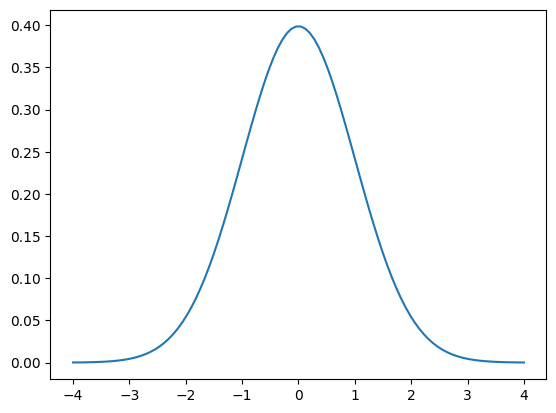

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
x= np.linspace(-4,4,100)
y=norm.pdf(x) # PDF here stands for Probability Density Function
plt.plot(x,y)
plt.show()

<Axes: ylabel='Count'>

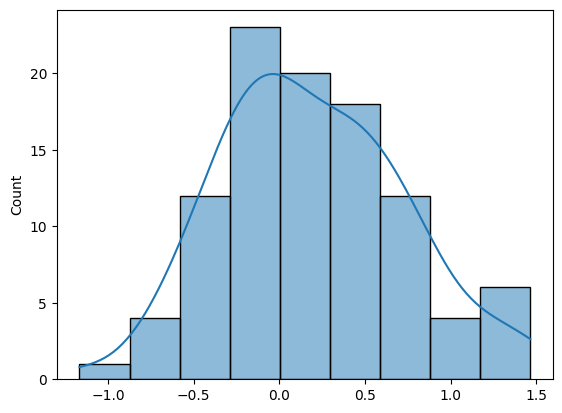

In [3]:
import seaborn as sns
import numpy as np
ser=np.random.normal(0.2,0.5,100)
sns.histplot(ser,kde=True)

Log distribution

<Axes: ylabel='Count'>

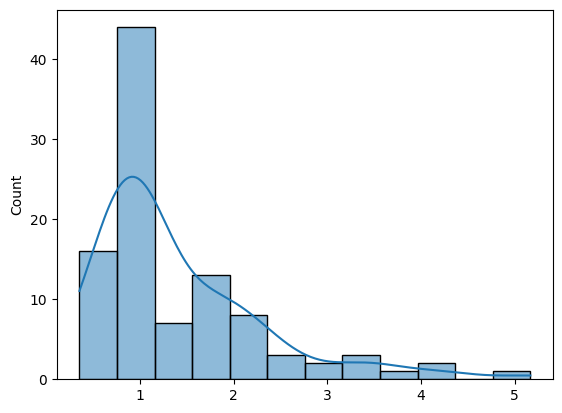

In [5]:
sns.histplot(np.random.lognormal(0.2,0.5,100),kde=True)

check whether the distribution is normal or not

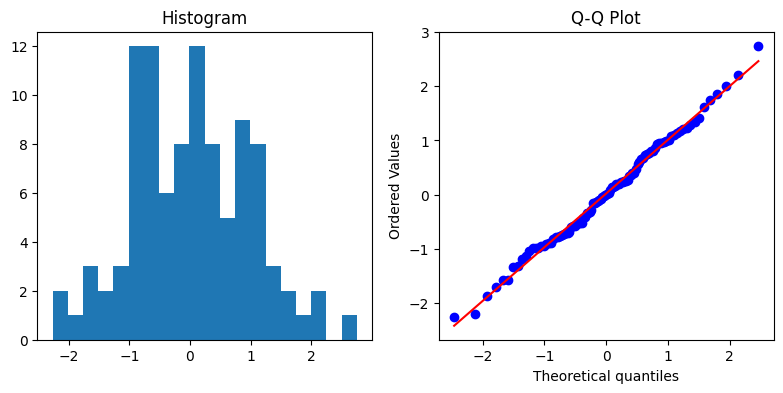

In [10]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.stats as stat
import pylab

def pyplot(sample):
  plt.figure(figsize=(9.5, 4)) # Adjusted figure size for better display
  plt.subplot(1,2,1)
  plt.hist(sample,bins=20)
  plt.title('Histogram')
  plt.subplot(1,2,2)
  stat.probplot(sample,dist='norm',plot=pylab)
  plt.title('Q-Q Plot')
  plt.show()

# Generate a sample and call the function to display the plots
sample_data = np.random.normal(0,1,100)
pyplot(sample_data)

Power Law in statistics

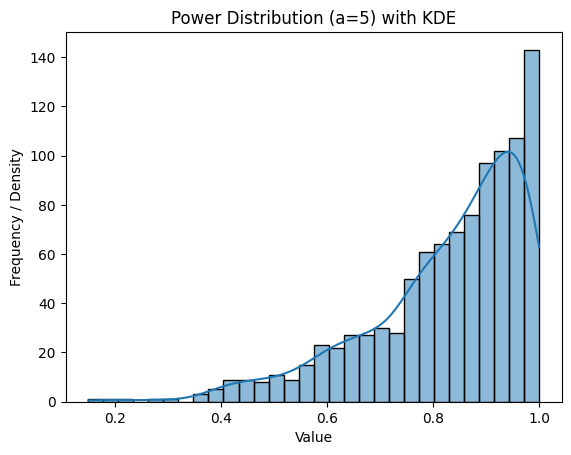

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for kde plotting

# 'a' is the exponent parameter for the power distribution
data = np.random.power(a=5, size=1000)

# Use seaborn's histplot to get KDE
sns.histplot(data, bins=30, kde=True)
plt.title(f'Power Distribution (a=5) with KDE')
plt.xlabel('Value')
plt.ylabel('Frequency / Density')
plt.show()

Box cox tranformation

In [2]:
from scipy import stats
import numpy as np

data = np.random.exponential(
    scale=2, size=500
)

# auto-find λ and transform
transformed, best_lambda = \
    stats.boxcox(data)

print(f"Best lambda: {best_lambda:.4f}")

# manual λ (no auto-search)
transformed_manual = \
    stats.boxcox(data, lmbda=0.5)

# normality test before
stat_before, p_before = \
    stats.normaltest(data)

# normality test after
stat_after, p_after = \
    stats.normaltest(transformed)

print(f"p-value before: {p_before:.4f}")
print(f"p-value after:  {p_after:.4f}")

Best lambda: 0.2564
p-value before: 0.0000
p-value after:  0.7187


### Visualizing the Box-Cox Transformation

To visually confirm the effect of the Box-Cox transformation, we'll plot the distribution of the original exponential data and the transformed data using histograms and Q-Q plots. This will allow us to compare their shapes and assess the improvement in normality.

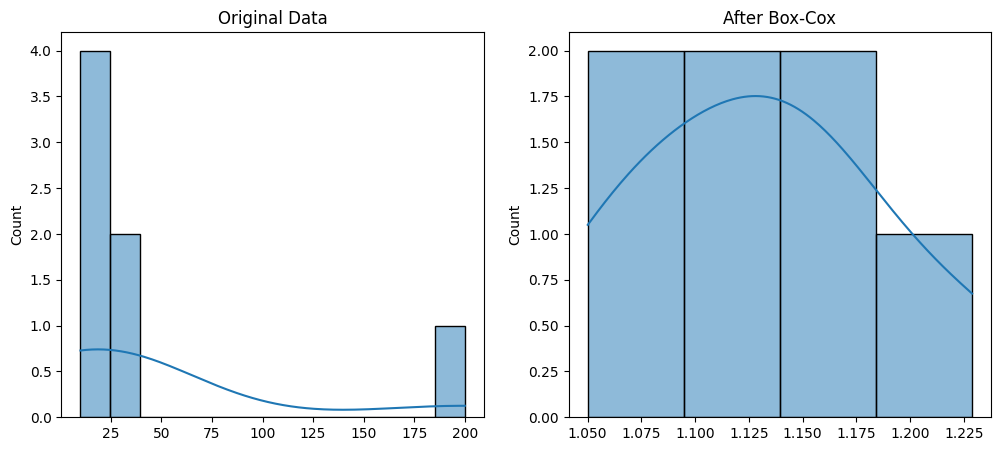

Lambda: -0.8021549345319047


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

# Skewed data
data = np.array([10, 12, 15, 20, 25, 30, 200])

# Before transformation
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Original Data")

# Box-Cox transform
transformed_data, lam = boxcox(data)

# After transformation
plt.subplot(1,2,2)
sns.histplot(transformed_data, kde=True)
plt.title("After Box-Cox")

plt.show()

print("Lambda:", lam)